<a href="https://colab.research.google.com/github/Sejal-Prajapati9/CodeAlpha_Credit_Scoring_Model/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 3 : **Handwritten Character Recognition**

---



# Libraries Import Aur Dataset Load Karna


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Dataset download aur load karna
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


#Data Preprocessing (Normalization & Reshaping)


In [2]:
# Pixels ko 0-1 ke beech scale karna
X_train, X_test = X_train / 255.0, X_test / 255.0

# CNN ke liye 4D shape me reshape karna (Batch_Size, Height, Width, Channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

#CNN Model Structure Design Karna

In [3]:
model = models.Sequential([
    # Pehli Convolutional layer aur Pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Doosri Convolutional layer aur Pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Layers classification ke liye
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 0 se 9 tak ke digits ke liye
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

#Model Compile Aur Train Karna

In [4]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Model ko 5 baar (epochs) poore data par train karna
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.9603 - loss: 0.1288 - val_accuracy: 0.9807 - val_loss: 0.0576
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9865 - loss: 0.0436 - val_accuracy: 0.9875 - val_loss: 0.0366
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9902 - loss: 0.0303 - val_accuracy: 0.9872 - val_loss: 0.0389
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9932 - loss: 0.0216 - val_accuracy: 0.9895 - val_loss: 0.0328
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9944 - loss: 0.0169 - val_accuracy: 0.9869 - val_loss: 0.0435


#Accuracy Check Karna Aur Output Dekhna

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9869 - loss: 0.0435

Final Test Accuracy: 98.69%


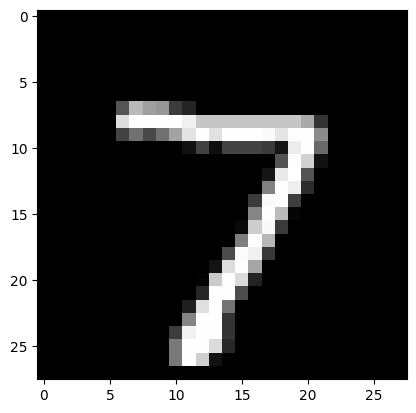

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Model ne predict kiya: 7


In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

# Kisi ek random test image par prediction check karna
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.show()

prediction = model.predict(X_test[0].reshape(1, 28, 28, 1))
print(f"Model ne predict kiya: {np.argmax(prediction)}")

In [6]:
# Model ko save karne ke liye
model.save('handwritten_digit_model.h5')
print("Model successfully save ho gaya hai!")

Model successfully save ho gaya hai!
